In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import xml.etree.ElementTree as ET
import ssl

# Disable SSL verification
ssl._create_default_https_context = ssl._create_unverified_context

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths (UPDATE THESE)
annotations_dir = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/annotations"
images_dir = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/images"

# Define classes - With Helmet = 1, Without Helmet = 0
classes = ['Without Helmet', 'With Helmet']  # Index 0: Without, Index 1: With
class_dict = {'Without Helmet': 0, 'With Helmet': 1}
num_classes = 2

Using device: cpu


In [14]:
class SimpleGoogleNetBackbone(nn.Module):
    """A simplified GoogleNet-like backbone that works offline"""
    def __init__(self, in_channels=3):
        super(SimpleGoogleNetBackbone, self).__init__()
        
        # Initial layers
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Inception-like blocks (simplified)
        self.conv2 = nn.Conv2d(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # More layers
        self.conv3 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Final layers
        self.conv6 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.maxpool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.maxpool2(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.maxpool3(x)
        
        x = F.relu(self.conv6(x))
        x = F.relu(self.conv7(x))
        
        return x

class GoogleNetWithROI(nn.Module):
    def __init__(self, num_classes=2, roi_size=7):
        super(GoogleNetWithROI, self).__init__()
        self.num_classes = num_classes
        self.roi_size = roi_size
        
        # Use custom backbone (works offline)
        self.backbone = SimpleGoogleNetBackbone()
        backbone_out_channels = 512
        
        # ROI Pooling
        self.roi_pool = nn.AdaptiveMaxPool2d((roi_size, roi_size))
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(backbone_out_channels * roi_size * roi_size, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Bounding box regression head
        self.bbox_pred = nn.Sequential(
            nn.Linear(backbone_out_channels * roi_size * roi_size, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes * 4)
        )
        
    def forward(self, images, rois):
        # Extract features from entire image
        features = self.backbone(images)
        
        # Apply ROI pooling for each region
        batch_size = images.size(0)
        pooled_features = []
        
        for i in range(batch_size):
            # Get ROIs for this batch item
            batch_rois = rois[rois[:, 0] == i]
            if len(batch_rois) == 0:
                continue
                
            for roi in batch_rois:
                _, x1, y1, x2, y2 = roi
                
                # Convert normalized coordinates to feature map coordinates
                h, w = features.shape[2], features.shape[3]
                x1_pix = int(x1 * w)
                y1_pix = int(y1 * h)
                x2_pix = int(x2 * w)
                y2_pix = int(y2 * h)
                
                # Ensure valid coordinates
                x1_pix = max(0, x1_pix)
                y1_pix = max(0, y1_pix)
                x2_pix = min(w, x2_pix)
                y2_pix = min(h, y2_pix)
                
                if x2_pix > x1_pix and y2_pix > y1_pix:
                    roi_feature = features[i:i+1, :, y1_pix:y2_pix, x1_pix:x2_pix]
                    pooled = self.roi_pool(roi_feature)
                    pooled_features.append(pooled)
                else:
                    # Invalid ROI, use zeros
                    pooled_features.append(torch.zeros(1, features.size(1), self.roi_size, self.roi_size, device=features.device))
        
        if not pooled_features:
            # Return empty tensors if no valid ROIs
            return torch.zeros(0, self.num_classes, device=features.device), torch.zeros(0, self.num_classes, 4, device=features.device)
        
        pooled_features = torch.cat(pooled_features, dim=0)
        
        # Flatten
        pooled_features = pooled_features.view(pooled_features.size(0), -1)
        
        # Classification
        class_logits = self.classifier(pooled_features)
        
        # Bounding box regression
        bbox_deltas = self.bbox_pred(pooled_features)
        bbox_deltas = bbox_deltas.view(pooled_features.size(0), self.num_classes, 4)
        
        return class_logits, bbox_deltas

class GoogleNetLoss(nn.Module):
    def __init__(self, lambda_reg=1.0):
        super(GoogleNetLoss, self).__init__()
        self.lambda_reg = lambda_reg
        self.cls_loss = nn.CrossEntropyLoss()
        self.bbox_loss = nn.SmoothL1Loss()
    
    def forward(self, class_logits, bbox_deltas, labels, bbox_targets):
        # Classification loss
        cls_loss = self.cls_loss(class_logits, labels)
        
        # Bounding box regression loss (only for positive samples)
        pos_mask = labels > 0  # With Helmet = 1
        if pos_mask.sum() > 0:
            bbox_loss = self.bbox_loss(
                bbox_deltas[pos_mask, labels[pos_mask]],
                bbox_targets[pos_mask]
            )
        else:
            bbox_loss = torch.tensor(0.0, device=class_logits.device)
        
        total_loss = cls_loss + self.lambda_reg * bbox_loss
        return total_loss, cls_loss, bbox_loss

In [15]:
class HelmetDataset(Dataset):
    def __init__(self, annotations_dir, images_dir, split='train', img_size=224):
        self.annotations_dir = annotations_dir
        self.images_dir = images_dir
        self.img_size = img_size
        
        # Get all annotation files
        if not os.path.exists(annotations_dir):
            raise FileNotFoundError(f"Annotations directory not found: {annotations_dir}")
        
        annotation_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]
        
        if len(annotation_files) == 0:
            raise FileNotFoundError(f"No XML files found in {annotations_dir}")
        
        # Split data
        train_files, val_files = train_test_split(annotation_files, test_size=0.2, random_state=42)
        
        if split == 'train':
            self.files = train_files
        else:
            self.files = val_files
            
    def parse_annotation(self, annotation_file):
        """Parse XML annotations to extract bounding boxes and labels"""
        annotation_path = os.path.join(self.annotations_dir, annotation_file)
        try:
            tree = ET.parse(annotation_path)
            root = tree.getroot()
            
            objects = []
            for obj in root.findall('object'):
                obj_struct = {}
                obj_struct['name'] = obj.find('name').text
                bbox = obj.find('bndbox')
                obj_struct['bbox'] = [
                    int(float(bbox.find('xmin').text)),
                    int(float(bbox.find('ymin').text)),
                    int(float(bbox.find('xmax').text)),
                    int(float(bbox.find('ymax').text))
                ]
                objects.append(obj_struct)
            return objects
        except Exception as e:
            print(f"Error parsing {annotation_file}: {e}")
            return []
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        annotation_file = self.files[idx]
        
        # Parse annotation
        objects = self.parse_annotation(annotation_file)
        
        # Load image - try different extensions
        image_name = annotation_file.replace('.xml', '')
        image_path = None
        
        for ext in ['.png', '.jpg', '.jpeg', '.JPG', '.JPEG']:
            potential_path = os.path.join(self.images_dir, image_name + ext)
            if os.path.exists(potential_path):
                image_path = potential_path
                break
        
        if image_path is None:
            # Create a dummy image if not found
            print(f"Image not found for {annotation_file}, creating dummy")
            image = np.ones((self.img_size, self.img_size, 3), dtype=np.uint8) * 128
            objects = [{'name': 'With Helmet', 'bbox': [50, 50, 100, 100]}]
        else:
            image = cv2.imread(image_path)
            if image is None:
                print(f"Could not read image: {image_path}")
                image = np.ones((self.img_size, self.img_size, 3), dtype=np.uint8) * 128
                objects = [{'name': 'With Helmet', 'bbox': [50, 50, 100, 100]}]
            else:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        original_h, original_w = image.shape[:2]
        
        # Prepare bounding boxes and labels
        boxes = []
        labels = []
        
        for obj in objects:
            xmin, ymin, xmax, ymax = obj['bbox']
            class_id = class_dict[obj['name']]  # With Helmet = 1, Without Helmet = 0
            
            # Normalize coordinates and clamp to [0, 1]
            xmin_norm = max(0.0, min(1.0, xmin / original_w))
            ymin_norm = max(0.0, min(1.0, ymin / original_h))
            xmax_norm = max(0.0, min(1.0, xmax / original_w))
            ymax_norm = max(0.0, min(1.0, ymax / original_h))
            
            # Skip invalid boxes
            if xmax_norm > xmin_norm and ymax_norm > ymin_norm:
                boxes.append([xmin_norm, ymin_norm, xmax_norm, ymax_norm])
                labels.append(class_id)
        
        if len(boxes) == 0:
            # If no valid objects, return dummy data
            boxes = [[0.1, 0.1, 0.5, 0.5]]
            labels = [1]  # Default to With Helmet
        
        # Resize image
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        # Convert to tensor and normalize
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        # Normalize for better training
        image_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image_tensor)
        
        boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.long)
        
        return image_tensor, {'boxes': boxes_tensor, 'labels': labels_tensor, 'image_id': idx}

In [16]:
def train_googlenet_helmet():
    print("Initializing GoogleNet Helmet Detection Training...")
    print(f"Class mapping: {classes}")
    print(f"Class dictionary: {class_dict}")
    
    # Create datasets
    train_dataset = HelmetDataset(annotations_dir, images_dir, split='train', img_size=224)
    val_dataset = HelmetDataset(annotations_dir, images_dir, split='val', img_size=224)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Custom collate function
    def collate_fn(batch):
        images = []
        targets = []
        
        for item in batch:
            images.append(item[0])
            targets.append(item[1])
        
        # Stack images
        images = torch.stack(images, dim=0)
        return images, targets
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)
    
    # Initialize model
    model = GoogleNetWithROI(num_classes=num_classes).to(device)
    criterion = GoogleNetLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    # Training loop
    num_epochs = 20
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        batch_count = 0
        
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(device)
            
            # Prepare ROIs from ground truth boxes
            batch_rois = []
            batch_labels = []
            batch_bbox_targets = []
            
            for i, target in enumerate(targets):
                boxes = target['boxes']
                labels = target['labels']
                
                if len(boxes) == 0:
                    continue
                    
                # Add batch index to boxes
                batch_indices = torch.full((len(boxes), 1), i, dtype=torch.float32)
                rois = torch.cat([batch_indices, boxes], dim=1)
                batch_rois.append(rois)
                batch_labels.append(labels)
                
                # For simplicity, use zero bbox targets
                bbox_targets = torch.zeros((len(boxes), 4), dtype=torch.float32)
                batch_bbox_targets.append(bbox_targets)
            
            if len(batch_rois) == 0:
                continue
                
            batch_rois = torch.cat(batch_rois, dim=0).to(device)
            batch_labels = torch.cat(batch_labels, dim=0).to(device)
            batch_bbox_targets = torch.cat(batch_bbox_targets, dim=0).to(device)
            
            # Forward pass
            optimizer.zero_grad()
            class_logits, bbox_deltas = model(images, batch_rois)
            
            # Compute loss
            total_loss, cls_loss, bbox_loss = criterion(
                class_logits, bbox_deltas, batch_labels, batch_bbox_targets
            )
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            batch_count += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx}, Loss: {total_loss.item():.4f}')
        
        if batch_count > 0:
            avg_loss = epoch_loss / batch_count
        else:
            avg_loss = 0
            
        train_losses.append(avg_loss)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                
                batch_rois = []
                batch_labels = []
                
                for i, target in enumerate(targets):
                    boxes = target['boxes']
                    labels = target['labels']
                    
                    if len(boxes) == 0:
                        continue
                        
                    batch_indices = torch.full((len(boxes), 1), i, dtype=torch.float32)
                    rois = torch.cat([batch_indices, boxes], dim=1)
                    batch_rois.append(rois)
                    batch_labels.append(labels)
                
                if len(batch_rois) == 0:
                    continue
                    
                batch_rois = torch.cat(batch_rois, dim=0).to(device)
                batch_labels = torch.cat(batch_labels, dim=0).to(device)
                
                class_logits, _ = model(images, batch_rois)
                preds = torch.argmax(class_logits, dim=1)
                correct += (preds == batch_labels).sum().item()
                total += len(batch_labels)
        
        accuracy = correct / total if total > 0 else 0
        val_accuracies.append(accuracy)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Accuracy: {accuracy:.4f}')
    
    # Save model
    torch.save(model.state_dict(), 'googlenet_helmet_detection.pth')
    print("Model saved as 'googlenet_helmet_detection.pth'")
    
    return model, train_losses, val_accuracies

In [17]:
def load_googlenet_model(model_path):
    """Load the trained GoogleNet model from .pth file"""
    model = GoogleNetWithROI(num_classes=num_classes)
    
    if os.path.exists(model_path):
        print(f"Loading GoogleNet model from: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()
        print("GoogleNet model loaded successfully!")
        return model
    else:
        print(f"Model file not found: {model_path}")
        return None

def generate_proposals(image_width, image_height, min_size=40, max_size=180, stride=40):
    """Generate region proposals using sliding window"""
    proposals = []
    
    # Multiple scales for better detection
    scales = [40, 60, 80, 100, 120]
    
    for size in scales:
        if size > min(image_width, image_height):
            continue
        for y in range(0, image_height - size + 1, stride):
            for x in range(0, image_width - size + 1, stride):
                proposals.append([x, y, x + size, y + size])
    
    return proposals

def googlenet_inference(model, image_path, confidence_threshold=0.7):
    """Perform inference using trained GoogleNet model"""
    if model is None:
        print("Model not loaded!")
        return [], None
        
    model.eval()
    
    # Load and preprocess image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return [], None
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = image_rgb.shape[:2]
    
    # Preprocess image
    image_resized = cv2.resize(image_rgb, (224, 224))
    image_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float() / 255.0
    image_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image_tensor)
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Generate region proposals
    proposals = generate_proposals(original_w, original_h)
    
    # Convert proposals to ROI format
    rois = []
    for proposal in proposals:
        x1, y1, x2, y2 = proposal
        # Normalize coordinates
        x1_norm = max(0.0, min(1.0, x1 / original_w))
        y1_norm = max(0.0, min(1.0, y1 / original_h))
        x2_norm = max(0.0, min(1.0, x2 / original_w))
        y2_norm = max(0.0, min(1.0, y2 / original_h))
        
        if x2_norm > x1_norm and y2_norm > y1_norm:
            rois.append([0, x1_norm, y1_norm, x2_norm, y2_norm])
    
    if not rois:
        return [], image_rgb
        
    rois = torch.tensor(rois, dtype=torch.float32).to(device)
    
    # Perform inference
    with torch.no_grad():
        class_logits, bbox_deltas = model(image_tensor, rois)
        probabilities = F.softmax(class_logits, dim=1)
        max_probs, pred_classes = torch.max(probabilities, dim=1)
    
    # Filter detections
    detections = []
    for i, (prob, class_id) in enumerate(zip(max_probs, pred_classes)):
        if prob >= confidence_threshold:
            x1, y1, x2, y2 = proposals[i]
            detections.append({
                'bbox': [x1, y1, x2, y2],
                'class_id': class_id.item(),
                'class_name': classes[class_id.item()],  # 0=Without Helmet, 1=With Helmet
                'confidence': prob.item()
            })
    
    return detections, image_rgb

def visualize_detections(image, detections):
    """Visualize detections on image"""
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
    # Draw detections
    for detection in detections:
        bbox = detection['bbox']
        class_name = detection['class_name']
        confidence = detection['confidence']
        
        # Choose color based on class
        if class_name == 'With Helmet':  # class_id = 1
            color = 'green'
            label_color = 'darkgreen'
        else:  # class_id = 0
            color = 'red'
            label_color = 'darkred'
        
        # Draw bounding box
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                           fill=False, edgecolor=color, linewidth=3)
        ax.add_patch(rect)
        
        # Add label with background
        label = f'{class_name}: {confidence:.2f}'
        ax.text(bbox[0], bbox[1] - 15, label, 
                color='white', fontsize=12, weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=label_color, alpha=0.8))
    
    ax.imshow(image)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [18]:
# Train the GoogleNet model
print("Starting GoogleNet Helmet Detection Training...")
print(f"Class Mapping: Without Helmet = 0, With Helmet = 1")
model, train_losses, val_accuracies = train_googlenet_helmet()
print("Training completed!")


Starting GoogleNet Helmet Detection Training...
Class Mapping: Without Helmet = 0, With Helmet = 1
Initializing GoogleNet Helmet Detection Training...
Class mapping: ['Without Helmet', 'With Helmet']
Class dictionary: {'Without Helmet': 0, 'With Helmet': 1}
Training samples: 611
Validation samples: 153
Epoch: 1/20, Batch: 0, Loss: 0.6960
Epoch: 1/20, Batch: 10, Loss: 0.6850
Epoch: 1/20, Batch: 20, Loss: 0.6471
Epoch: 1/20, Batch: 30, Loss: 0.6601
Epoch: 1/20, Batch: 40, Loss: 0.6103
Epoch: 1/20, Batch: 50, Loss: 0.5489
Epoch: 1/20, Batch: 60, Loss: 0.5593
Epoch: 1/20, Batch: 70, Loss: 0.7933
Epoch 1/20, Loss: 0.6454, Val Accuracy: 0.6622
Epoch: 2/20, Batch: 0, Loss: 0.6875
Epoch: 2/20, Batch: 10, Loss: 0.6447
Epoch: 2/20, Batch: 20, Loss: 0.4654
Epoch: 2/20, Batch: 30, Loss: 0.6832
Epoch: 2/20, Batch: 40, Loss: 0.5290
Epoch: 2/20, Batch: 50, Loss: 0.7046
Epoch: 2/20, Batch: 60, Loss: 0.3979
Epoch: 2/20, Batch: 70, Loss: 0.5793
Epoch 2/20, Loss: 0.6271, Val Accuracy: 0.6622
Epoch: 3/20,

Testing GoogleNet on custom image...
Loading GoogleNet model from: googlenet_helmet_detection.pth
GoogleNet model loaded successfully!
Processing: BikesHelmets26.png
Class Legend: Green = With Helmet (1), Red = Without Helmet (0)

--- Testing with confidence threshold: 0.6 ---
Detections in BikesHelmets26.png (threshold: 0.6):
  - With Helmet (Class 1): 0.813
  - Without Helmet (Class 0): 0.763
  - With Helmet (Class 1): 0.741
  - With Helmet (Class 1): 0.611
  - With Helmet (Class 1): 0.786
  - With Helmet (Class 1): 0.784
  - Without Helmet (Class 0): 0.763
  - Without Helmet (Class 0): 0.935
  - Without Helmet (Class 0): 0.926
  - Without Helmet (Class 0): 0.892
  - Without Helmet (Class 0): 0.767
  - Without Helmet (Class 0): 0.748
  - Without Helmet (Class 0): 0.604
  - With Helmet (Class 1): 0.655
  - Without Helmet (Class 0): 0.869
  - With Helmet (Class 1): 0.700
  - Without Helmet (Class 0): 0.614
  - Without Helmet (Class 0): 0.896
  - Without Helmet (Class 0): 0.936
  - With

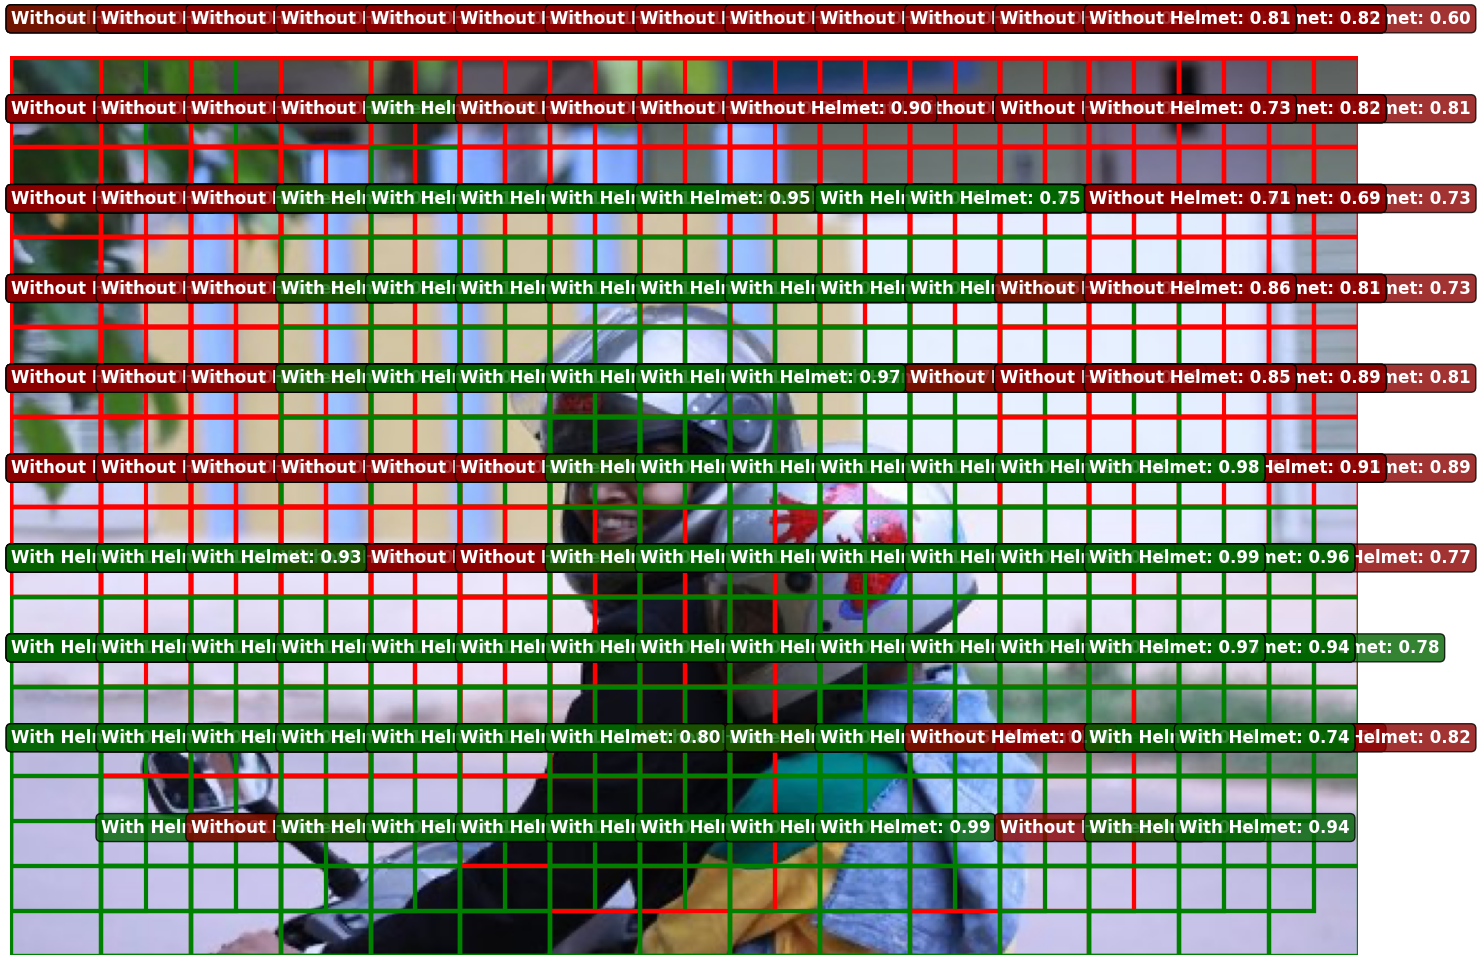


--- Testing with confidence threshold: 0.7 ---
Detections in BikesHelmets26.png (threshold: 0.7):
  - With Helmet (Class 1): 0.813
  - Without Helmet (Class 0): 0.763
  - With Helmet (Class 1): 0.741
  - With Helmet (Class 1): 0.786
  - With Helmet (Class 1): 0.784
  - Without Helmet (Class 0): 0.763
  - Without Helmet (Class 0): 0.935
  - Without Helmet (Class 0): 0.926
  - Without Helmet (Class 0): 0.892
  - Without Helmet (Class 0): 0.767
  - Without Helmet (Class 0): 0.748
  - Without Helmet (Class 0): 0.869
  - Without Helmet (Class 0): 0.896
  - Without Helmet (Class 0): 0.936
  - Without Helmet (Class 0): 0.866
  - Without Helmet (Class 0): 0.929
  - Without Helmet (Class 0): 0.956
  - Without Helmet (Class 0): 0.948
  - Without Helmet (Class 0): 0.910
  - Without Helmet (Class 0): 0.902
  - Without Helmet (Class 0): 0.925
  - Without Helmet (Class 0): 0.807
  - Without Helmet (Class 0): 0.743
  - Without Helmet (Class 0): 0.930
  - Without Helmet (Class 0): 0.850
  - Without H

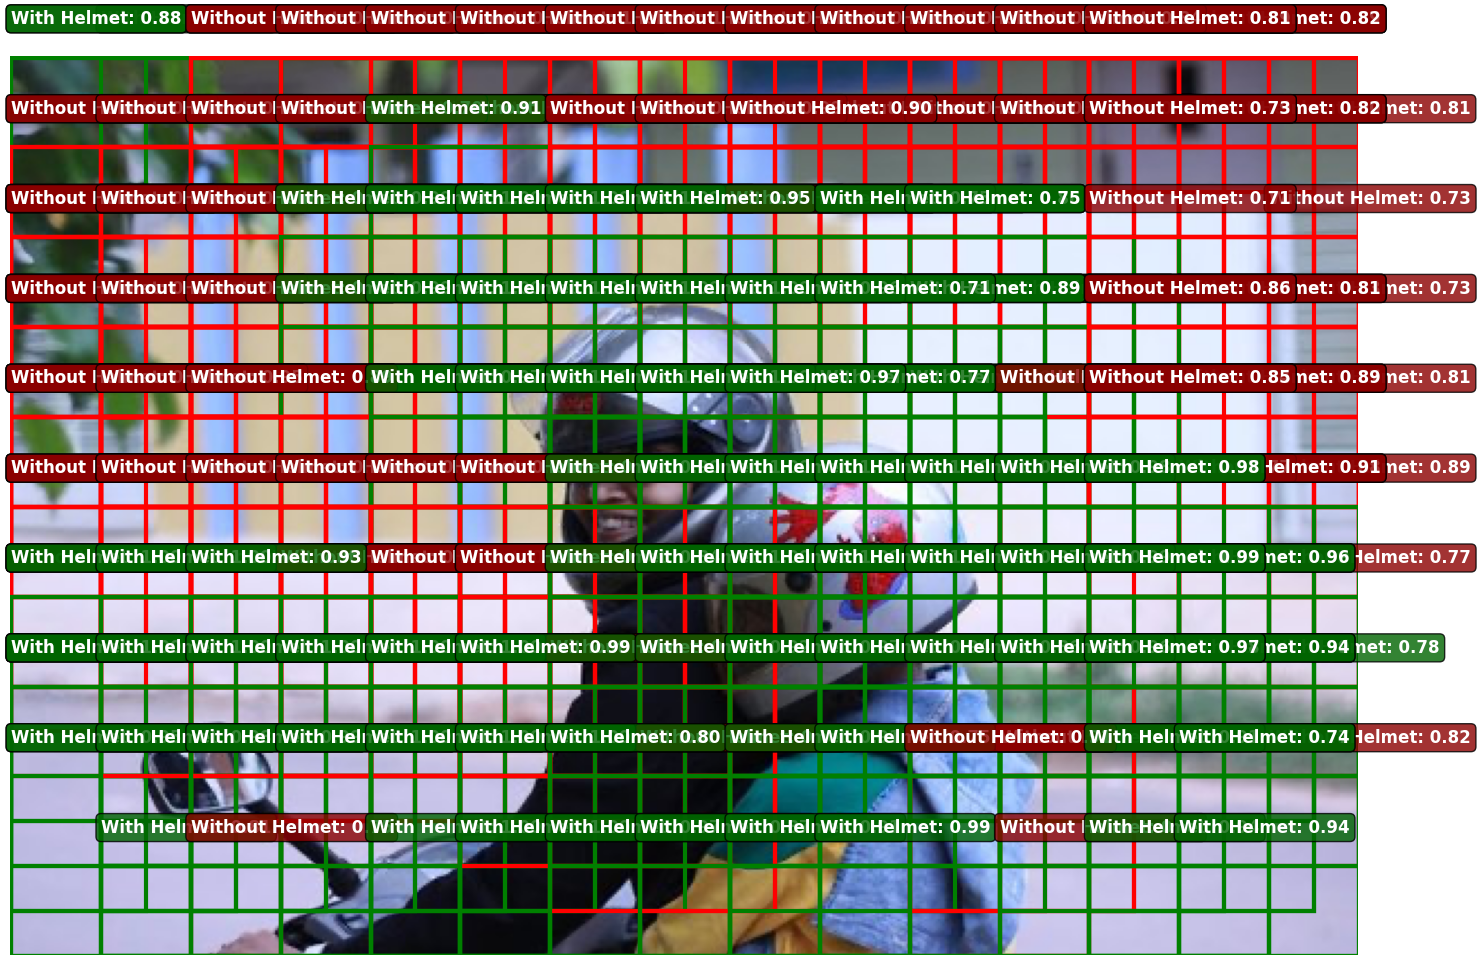


--- Testing with confidence threshold: 0.8 ---
Detections in BikesHelmets26.png (threshold: 0.8):
  - With Helmet (Class 1): 0.813
  - Without Helmet (Class 0): 0.935
  - Without Helmet (Class 0): 0.926
  - Without Helmet (Class 0): 0.892
  - Without Helmet (Class 0): 0.869
  - Without Helmet (Class 0): 0.896
  - Without Helmet (Class 0): 0.936
  - Without Helmet (Class 0): 0.866
  - Without Helmet (Class 0): 0.929
  - Without Helmet (Class 0): 0.956
  - Without Helmet (Class 0): 0.948
  - Without Helmet (Class 0): 0.910
  - Without Helmet (Class 0): 0.902
  - Without Helmet (Class 0): 0.925
  - Without Helmet (Class 0): 0.807
  - Without Helmet (Class 0): 0.930
  - Without Helmet (Class 0): 0.850
  - Without Helmet (Class 0): 0.989
  - Without Helmet (Class 0): 1.000
  - Without Helmet (Class 0): 1.000
  - Without Helmet (Class 0): 1.000
  - Without Helmet (Class 0): 1.000
  - Without Helmet (Class 0): 0.957
  - Without Helmet (Class 0): 0.833
  - Without Helmet (Class 0): 0.942
  - 

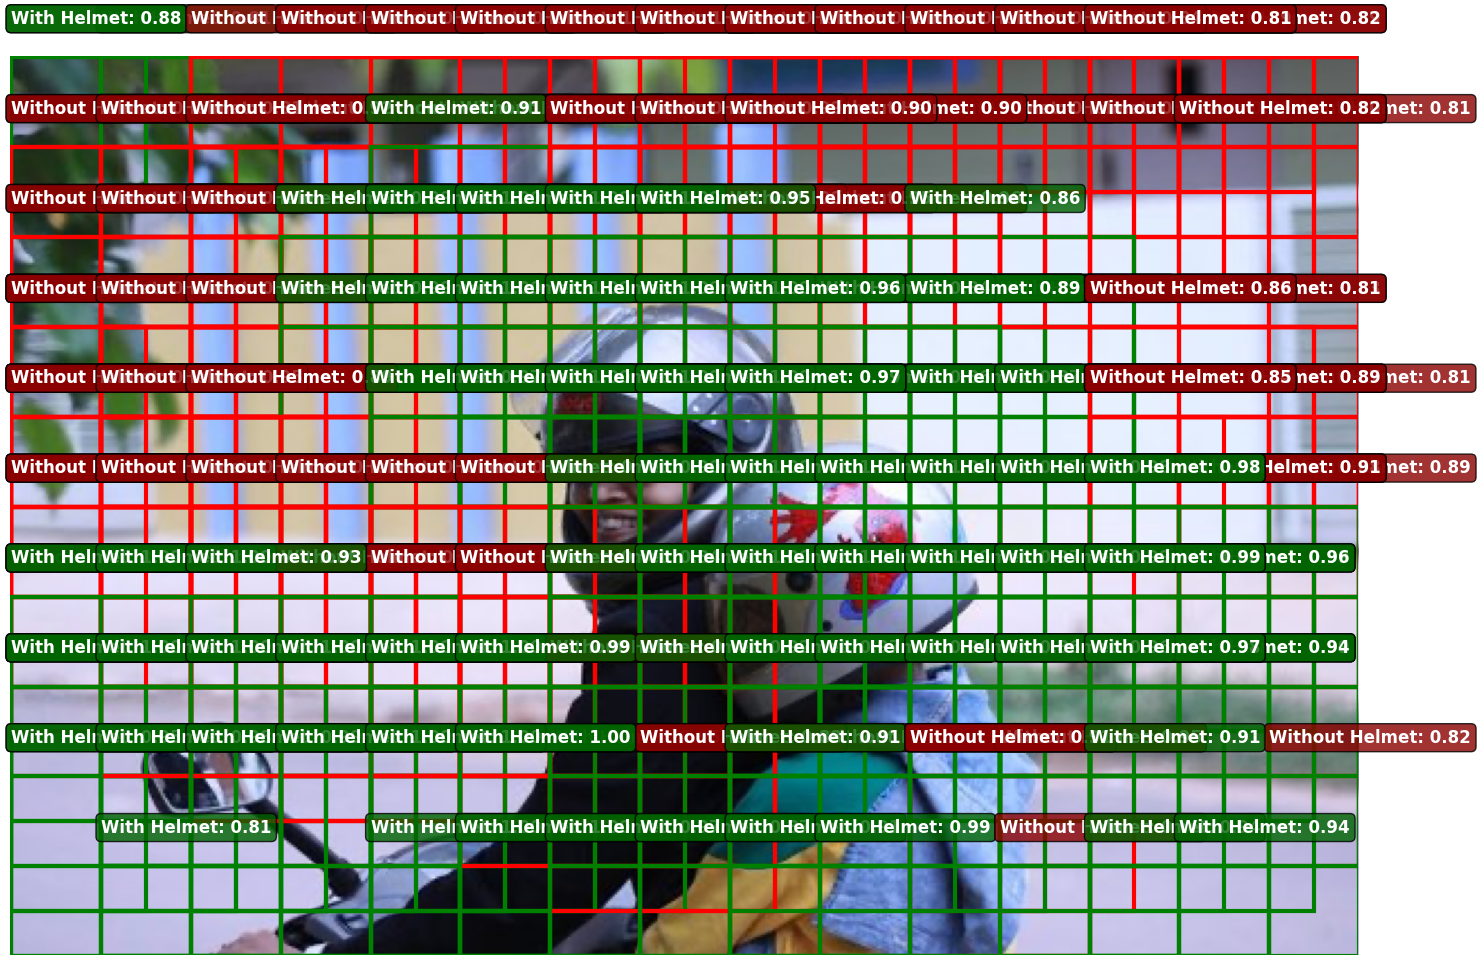

GoogleNet helmet detection testing completed!


In [22]:
# Test on custom image using GoogleNet
print("Testing GoogleNet on custom image...")

#Load the trained model (use this if you want to load without retraining)
model_path = 'googlenet_helmet_detection.pth'
model = load_googlenet_model(model_path)

# SPECIFY YOUR CUSTOM TEST IMAGE PATH HERE
custom_test_image_path = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/images/BikesHelmets26.png"  # ← CHANGE THIS

if os.path.exists(custom_test_image_path):
    print(f"Processing: {os.path.basename(custom_test_image_path)}")
    print(f"Class Legend: Green = With Helmet (1), Red = Without Helmet (0)")
    
    # Try different confidence thresholds
    for confidence_thresh in [0.6, 0.7, 0.8]:
        print(f"\n--- Testing with confidence threshold: {confidence_thresh} ---")
        
        detections, image = googlenet_inference(model, custom_test_image_path, confidence_threshold=confidence_thresh)
        
        if detections:
            print(f"Detections in {os.path.basename(custom_test_image_path)} (threshold: {confidence_thresh}):")
            with_helmet_count = 0
            without_helmet_count = 0
            
            for det in detections:
                if det['class_id'] == 1:  # With Helmet
                    with_helmet_count += 1
                else:  # Without Helmet
                    without_helmet_count += 1
                print(f"  - {det['class_name']} (Class {det['class_id']}): {det['confidence']:.3f}")
            
            print(f"Summary: With Helmet: {with_helmet_count}, Without Helmet: {without_helmet_count}")
            
            # Visualize only if we have detections
            visualize_detections(image, detections)
        else:
            print(f"No detections found with confidence threshold: {confidence_thresh}")
else:
    print(f"Test image not found: {custom_test_image_path}")

print("GoogleNet helmet detection testing completed!")